2. Task: Linear Regression for Medical Cost Prediction
Following the given example, build a linear regression model for the insurance dataset to predict the medical cost.

2.1 Preprocess the raw data
Based on your Lab Assignment 2, deal with the missing values and categorical features.

In [17]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_absolute_error,mean_squared_error
import matplotlib.pyplot as plt


df = pd.read_csv('insurance.csv')

# 0. fill in missing values
print(df.isnull().sum())

# 1. convert categorical features to numerical values
labelencoder = LabelEncoder()
df['sex'] = labelencoder.fit_transform(df['sex'])
print(df['sex'].value_counts())

df['smoker'] = labelencoder.fit_transform(df['smoker'])
print(df['smoker'].value_counts())

df['region'] = labelencoder.fit_transform(df['region'])
print(df['region'].value_counts())

print(df.info())

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64
sex
1    676
0    662
Name: count, dtype: int64
smoker
0    1064
1     274
Name: count, dtype: int64
region
2    364
3    325
1    325
0    324
Name: count, dtype: int64
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   int64  
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   int64  
 5   region    1338 non-null   int64  
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(5)
memory usage: 73.3 KB
None


2.2 Split the preprocessed dataset into training set and testing set
Use 80% of samples as the training set and 20% of samples as the testing set

In [36]:
# 2. split samples
insurance_fea = df.drop('charges', axis=1).values
insurance_charges = df['charges'].values
insurance_charges = insurance_charges / np.max(insurance_charges)

X_train,X_test,y_train,y_test = train_test_split(insurance_fea,
                                                 insurance_charges,
                                                 test_size=0.2,
                                                 random_state=42)
print(X_train.shape)
print(X_test.shape)


# normalize features
normalizer = StandardScaler()
X_train = normalizer.fit_transform(X_train)
X_test = normalizer.transform(X_test)

(1070, 6)
(268, 6)


2.3 Train the linear regression model

Use the Linear regression model to do prediction
Please output the learned model parameter and see how the learned model fit the training set.

In [23]:
#3. train the model
lr = LinearRegression()

lr.fit(X_train,y_train)

print("Bias is "+str(lr.intercept_))
print("Coefficients  are "+str(lr.coef_))

y_train_pred = lr.predict(X_train)

mae = mean_absolute_error(y_train_pred,y_train)
mse = mean_squared_error(y_train_pred,y_train)
rmse = np.sqrt(mse)

print('Prediction for training set:')
print('MAE is: {}'.format(mae))
print('MSE is: {}'.format(mse))
print('RMSE is: {}'.format(rmse))

Bias is 0.20928336460705027
Coefficients  are [ 5.67051024e-02 -1.47293258e-04  3.18064131e-02  8.10191467e-03
  1.49867951e-01 -4.74182139e-03]
Prediction for training set:
MAE is: 0.06599864797091508
MSE is: 0.00916737434945697
RMSE is: 0.09574640645714579


2.4 Evaluate the linear regression model

Evaluate the learned model to see how well this model generaizes on the testing set.

Prediction for testing set:
MAE is: 0.06564969107169766
MSE is: 0.008270951713078177
RMSE is: 0.09094477287386107


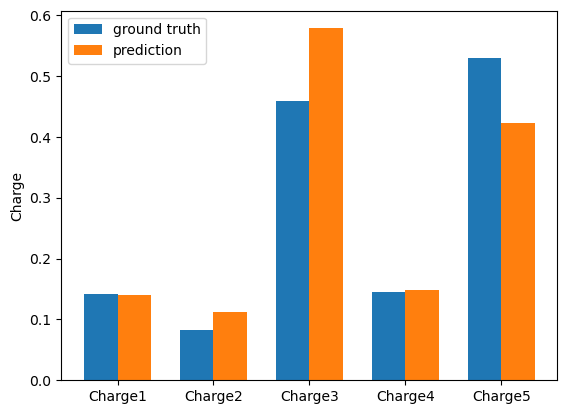

In [25]:
#4. evaluate the model
y_test_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test_pred,y_test)
mse = mean_squared_error(y_test_pred,y_test)
rmse = np.sqrt(mse)

print('Prediction for testing set:')
print('MAE is: {}'.format(mae))
print('MSE is: {}'.format(mse))
print('RMSE is: {}'.format(rmse))


labels = ['Charge1', 'Charge2', 'Charge3', 'Charge4', 'Charge5']
x = np.arange(len(labels))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots()
rects1 = ax.bar(x - width/2, y_test[0:5], width, label='ground truth')
rects2 = ax.bar(x + width/2, y_test_pred[0:5], width, label='prediction')

ax.set_ylabel('Charge')
ax.set_xticks(x)
ax.set_xticklabels(labels)
ax.legend()

plt.show()

2.5 Use the ridge regression model to do prediction

2.5.1 Compare its performance on the testing set with that of the standard linear regression model 

2.5.2 Use different lambda to see how it affects the performance of the ridge regression model on the testing set

In [34]:
lr = Ridge(alpha=0.1)
print("Lambda = 0.1")
lr.fit(X_train, y_train)
print("Bias is "+str(lr.intercept_))
print("Coefficients are " + str(lr.coef_))

y_test_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test_pred,y_test)
mse = mean_squared_error(y_test_pred,y_test)
rmse = np.sqrt(mse)

print('Prediction for testing set:')
print('MAE is: {}'.format(mae))
print('MSE is: {}'.format(mse))
print('RMSE is: {}'.format(rmse))

lr = Ridge(alpha=1)
print("\nLambda = 1")
lr.fit(X_train, y_train)
print("Bias is "+str(lr.intercept_))
print("Coefficients are " + str(lr.coef_))

y_test_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test_pred,y_test)
mse = mean_squared_error(y_test_pred,y_test)
rmse = np.sqrt(mse)

print('Prediction for testing set:')
print('MAE is: {}'.format(mae))
print('MSE is: {}'.format(mse))
print('RMSE is: {}'.format(rmse))

lr = Ridge(alpha=10)
print("\nLambda = 10")
lr.fit(X_train, y_train)
print("Bias is "+str(lr.intercept_))
print("Coefficients are " + str(lr.coef_))

y_test_pred = lr.predict(X_test)

mae = mean_absolute_error(y_test_pred,y_test)
mse = mean_squared_error(y_test_pred,y_test)
rmse = np.sqrt(mse)

print('Prediction for testing set:')
print('MAE is: {}'.format(mae))
print('MSE is: {}'.format(mse))
print('RMSE is: {}'.format(rmse))

Lambda = 0.1
Bias is 0.20928336460705027
Coefficients are [ 5.66993576e-02 -1.46253412e-04  3.18039167e-02  8.10168706e-03
  1.49853576e-01 -4.74098902e-03]
Prediction for testing set:
MAE is: 0.06565198712488937
MSE is: 0.008271112026766069
RMSE is: 0.09094565424893082

Lambda = 1
Bias is 0.20928336460705027
Coefficients are [ 5.66477072e-02 -1.36912304e-04  3.17814658e-02  8.09963575e-03
  1.49724329e-01 -4.73350751e-03]
Prediction for testing set:
MAE is: 0.06567262940074657
MSE is: 0.008272576669548302
RMSE is: 0.09095370618918341

Lambda = 10
Bias is 0.20928336460705027
Coefficients are [ 5.61363921e-02 -4.52097563e-05  3.15586307e-02  8.07885523e-03
  1.48444086e-01 -4.65965621e-03]
Prediction for testing set:
MAE is: 0.0658870235688507
MSE is: 0.008289340687239466
RMSE is: 0.09104581641810604
